In [173]:
import os
import sys
import contextlib

from matplotlib import pyplot as plt
import numpy as np

import mne
import mne_icalabel
from asrpy import ASR

def load_subject_data(file_path):
    # Load the .set file using mne
    return mne.io.read_raw_eeglab(file_path, preload=True)

def notch_highpass_bads_rereference(data: mne.io.Raw, notch_freq=60, highpass_freq=1, bads=None):
    dataCopy = data.copy()
    dataCopy.notch_filter(freqs=notch_freq, verbose=False)
    dataCopy.filter(l_freq=highpass_freq, h_freq=None, verbose=False)
    if bads is not None:
        dataCopy.info['bads'].extend(bads)
    dataCopy.set_eeg_reference('average', verbose=False)
    return dataCopy

def run_ica(data: mne.io.Raw, n_components=None, exclude=None, plot_sources=False):
    dataCopy = data.copy()

    ica = mne.preprocessing.ICA(n_components=n_components, random_state=0, method='infomax', fit_params=dict(extended=True))
    ica.fit(dataCopy, verbose=False)
    ica.exclude = exclude
    if exclude is None:
        labels = mne_icalabel.label_components(dataCopy, ica, method='iclabel')
        ica.exclude = [idx for idx, label in enumerate(labels['labels']) if label != 'brain']
    else:
        ica.exclude = exclude
    if plot_sources:
        plot = ica.plot_sources(dataCopy)
    icaData = ica.apply(dataCopy, verbose=False)

    return icaData

def run_asr(data: mne.io.Raw, calibration_start=0, calibration_end=60, cutoff=10, win_overlap=0.9, max_bad_chans=0.1):
    dataCopy = data.copy()

    asr = ASR(dataCopy.info['sfreq'], cutoff=cutoff, win_overlap=win_overlap, max_bad_chans=max_bad_chans)
    asr.fit(dataCopy.copy().crop(calibration_start, calibration_end))
    asrData = asr.transform(dataCopy)
    asrData.set_eeg_reference('average', verbose=False)
    return asrData

def bandpass_filter(data: mne.io.Raw, l_freq, h_freq):
    return data.copy().filter(l_freq=l_freq, h_freq=h_freq, method="fir", verbose=False)

def epoch_data(data: mne.io.Raw, e_start, e_end):
    epochs = mne.Epochs(data, tmin=e_start, tmax=e_end, baseline=None, preload=True, verbose=False)
    return epochs

def epoch_data_baseline(data: mne.io.Raw, b_start, b_end, e_start, e_end):
    epochs = mne.Epochs(data, tmin=b_start, tmax=e_end, baseline=(b_start,b_end), preload=True, verbose=False)
    epochs.crop(tmin=e_start, tmax=e_end)
    return epochs

def left_right_power(epochs: mne.Epochs, band, left_task, right_task, left_channels, right_channels):
    epochsCopy = epochs.copy()
    epochsCopy.drop_channels(epochsCopy.info['bads'])

    psd = epochsCopy.compute_psd(fmin=band[0], fmax=band[1])

    psd_left = psd[left_task]
    psd_right = psd[right_task]

    psd_left_data = psd_left.get_data() # Shape: (n_epochs, n_channels, n_freqs)
    psd_right_data = psd_right.get_data()

    left_mean_power = psd_left_data.mean(axis=-1) # Shape: (n_epochs, n_channels)
    right_mean_power = psd_right_data.mean(axis=-1)

    left_channel_indices = [epochsCopy.ch_names.index(ch) for ch in left_channels]
    right_channel_indices = [epochsCopy.ch_names.index(ch) for ch in right_channels]

    left_hand_left_brain = left_mean_power[:, left_channel_indices].mean(axis=-1)
    left_hand_right_brain = left_mean_power[:, right_channel_indices].mean(axis=-1)
    right_hand_left_brain = right_mean_power[:, left_channel_indices].mean(axis=-1)
    right_hand_right_brain = right_mean_power[:, right_channel_indices].mean(axis=-1)

    return (left_hand_left_brain, left_hand_right_brain, right_hand_left_brain, right_hand_right_brain)

In [174]:
%matplotlib ipympl

In [133]:
def calculate_subject_alpha_powers(subject, bads=None, show_plots=False, n_components=15, ica_exclude=None, use_asr=True, epoch_start=0, epoch_end=4):
    left_coi = ["Fc1", "Fc3", "C1", "C3", "Cp1", "Cp3"]
    right_coi = ["Fc2", "Fc4", "C2", "C4", "Cp2", "Cp4"]

    file_path = f"EEG Motor Movement:Imagery Dataset/sub-{subject}/eeg/sub-{subject}_task-motion_run-3_eeg.set"
    data = load_subject_data(file_path)
    # if subject == '002':
    #     data = data.crop(0, 113)
    data = notch_highpass_bads_rereference(data, notch_freq=60, highpass_freq=1, bads=bads)
    if show_plots: data.plot(duration=10, scalings={'eeg': 50e-6})
    data = run_ica(data, n_components, ica_exclude, plot_sources=show_plots)
    if show_plots: data.plot(duration=10, scalings={'eeg': 50e-6})
    if use_asr:
        data = run_asr(data, cutoff=20, calibration_end=30)
        if show_plots: data.plot(duration=10, scalings={'eeg': 50e-6})
    # data = bandpass_filter(data, 8, 30)
    # if show_plots: data.plot(duration=10, scalings={'eeg': 50e-6})
    epochs = epoch_data(data, epoch_start, epoch_end)

    return left_right_power(epochs, (8, 13), 'TASK1T1', 'TASK1T2', left_coi, right_coi)

In [67]:
def plot_subject_alpha_topoplot(subject, left_axes, right_axes, bads=None, n_components=15, ica_exclude=None, use_asr=True, epoch_start=0, epoch_end=1):
    coi = ["Fc1", "Fc3", "C1", "C3", "Cp1", "Cp3"] + ["Fc2", "Fc4", "C2", "C4", "Cp2", "Cp4"] + ["Fcz", "Cz", "Cpz"] #+ ["Fc5", "Fc6", "C5", "C6", "Cp5", "Cp6"]
    file_path = f"EEG Motor Movement:Imagery Dataset/sub-{subject}/eeg/sub-{subject}_task-motion_run-3_eeg.set"
    data = load_subject_data(file_path)
    if subject == '002':
        data = data.crop(0, 113)
    data = notch_highpass_bads_rereference(data, notch_freq=60, highpass_freq=1, bads=bads)
    data = run_ica(data, n_components, ica_exclude, plot_sources=False)
    if use_asr:
        data = run_asr(data, cutoff=20, calibration_end=30)
    data = bandpass_filter(data, 8, 30)
    epochs = epoch_data(data, -2, 0, epoch_start, epoch_end)
    # epochs.drop_channels(epochs.info['bads'])
    left_epochs = epochs['TASK1T1']
    right_epochs = epochs['TASK1T2']

    p = left_epochs.compute_psd(fmin=8, fmax=13, picks=coi).plot_topomap(bands = {'Alpha (8-13 Hz)': (8, 13)}, extrapolate='local', axes=left_axes)
    left_axes.set_title("Left Hand Alpha Power, Subject: " + subject)
    p = right_epochs.compute_psd(fmin=8, fmax=13, picks=coi).plot_topomap(bands = {'Alpha (8-13 Hz)': (8, 13)}, extrapolate='local', axes=right_axes)
    right_axes.set_title("Right Hand Alpha Power, Subject: " + subject)

In [291]:
def subject_epochs(subject, run=3, bads=None, show_plots=False, n_components=15, ica_exclude=None, use_asr=True, des=0, dee=3, bes=1, bee=4):
    file_path = f"EEG Motor Movement:Imagery Dataset/sub-{subject}/eeg/sub-{subject}_task-motion_run-{run}_eeg.set"
    data = load_subject_data(file_path)
    data = notch_highpass_bads_rereference(data, notch_freq=60, highpass_freq=1, bads=bads)
    if show_plots: data.plot(duration=10, scalings={'eeg': 50e-6})
    data = run_ica(data, n_components, ica_exclude, plot_sources=show_plots)
    if show_plots: data.plot(duration=10, scalings={'eeg': 50e-6})
    if use_asr:
        data = run_asr(data, cutoff=20, calibration_end=30)
        if show_plots: data.plot(duration=10, scalings={'eeg': 50e-6})
    data = bandpass_filter(data, 8, 30)
    data_epochs = epoch_data(data, des, dee)
    baseline_epochs = epoch_data(data, bes, bee)
    return data_epochs, baseline_epochs

In [292]:
def alpha_from_epochs(data_epochs, baseline_epochs, band=(8,13)):
    # left_coi = ["Fc1", "Fc3", "C1", "C3", "Cp1", "Cp3"]
    # right_coi = ["Fc2", "Fc4", "C2", "C4", "Cp2", "Cp4"]
    # left_coi = ["Fc3", "C3", "Cp3"]
    # right_coi = ["Fc4", "C4", "Cp4"]
    left_coi = ["C3"]
    right_coi = ["C4"]
    data_epochs_copy = data_epochs.copy()
    baseline_epochs_copy = baseline_epochs.copy()
    data_epochs_copy.drop_channels(data_epochs_copy.info['bads'])
    baseline_epochs_copy.drop_channels(baseline_epochs_copy.info['bads'])

    data_psd = data_epochs_copy.compute_psd(fmin=band[0], fmax=band[1])
    baseline_psd = baseline_epochs_copy.compute_psd(fmin=band[0], fmax=band[1])

    left_channel_indices = [data_epochs_copy.ch_names.index(ch) for ch in left_coi]
    right_channel_indices = [data_epochs_copy.ch_names.index(ch) for ch in right_coi]

    psd_base = baseline_psd['TASK1T0']
    psd_base_data = psd_base.get_data() # Shape: (n_epochs, n_channels, n_freqs)
    base_mean_power = psd_base_data.mean(axis=-1) # Shape: (n_epochs, n_channels)
    base_left_brain = base_mean_power[:, left_channel_indices].mean(axis=-1)
    base_right_brain = base_mean_power[:, right_channel_indices].mean(axis=-1)

    psd_left = data_psd['TASK1T1']
    psd_left_data = psd_left.get_data() # Shape: (n_epochs, n_channels, n_freqs)
    left_mean_power = psd_left_data.mean(axis=-1) # Shape: (n_epochs, n_channels)
    left_hand_left_brain = left_mean_power[:, left_channel_indices].mean(axis=-1)
    left_hand_right_brain = left_mean_power[:, right_channel_indices].mean(axis=-1)

    psd_right = data_psd['TASK1T2']
    psd_right_data = psd_right.get_data() # Shape: (n_epochs, n_channels, n_freqs)
    right_mean_power = psd_right_data.mean(axis=-1) # Shape: (n_epochs, n_channels)
    right_hand_left_brain = right_mean_power[:, left_channel_indices].mean(axis=-1)
    right_hand_right_brain = right_mean_power[:, right_channel_indices].mean(axis=-1)

    base_idx = 0
    left_idx = 0
    right_idx = 0

    modified_left_hand_left = []
    modified_left_hand_right = []
    modified_right_hand_left = []
    modified_right_hand_right = []

    for e in data_epochs.events[:, 2]:
        if e == 1:
            # This event is a base; get the base power values for subtraction.
            current_base_left = base_left_brain[base_idx]
            current_base_right = base_right_brain[base_idx]
            base_idx += 1
        elif e == 2:
            # This event is a left-hand trial: subtract the immediately preceding base.
            mod_lhlb = left_hand_left_brain[left_idx] - current_base_left
            mod_lhrb = left_hand_right_brain[left_idx] - current_base_right
            modified_left_hand_left.append(mod_lhlb)
            modified_left_hand_right.append(mod_lhrb)
            left_idx += 1
        elif e == 3:
            # This event is a right-hand trial: subtract the immediately preceding base.
            mod_rhlb = right_hand_left_brain[right_idx] - current_base_left
            mod_rhrb = right_hand_right_brain[right_idx] - current_base_right
            modified_right_hand_left.append(mod_rhlb)
            modified_right_hand_right.append(mod_rhrb)
            right_idx += 1

    return (np.array(modified_left_hand_left) * 1e12, np.array(modified_left_hand_right) * 1e12, 
            np.array(modified_right_hand_left) * 1e12, np.array(modified_right_hand_right) * 1e12)

In [ ]:
from mne.decoding import CSP
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score

subjects = [f"{i:03d}" for i in range(1, 110)]
runs = [3, 7, 11]
all_epochs = []

for s in subjects:
    epochs_list = []
    for r in runs:
        try:
            data_epochs, _ = subject_epochs(s, run=r)
            epochs_list.append(data_epochs['TASK1T1', 'TASK1T2'])
        except:
            print(f"Error processing subject {s} run {r}")

    combined_epochs = mne.concatenate_epochs(epochs_list)
    all_epochs.append(combined_epochs)


In [309]:
tests = range(5, 16)

results = []

for sub in range(len(subjects)):

    all_scores = []
    all_stds = []

    for i in tests:
        # Create the input data X and binary labels y:
        X = all_epochs[sub].get_data()  # shape is (n_trials, n_channels, n_times)
        y = (all_epochs[sub].events[:, 2] == 3).astype(int)  # 1 if event==3 (right-hand), else 0

        # Define the CSP transformer—here we use 4 components (adjust as needed)
        csp = CSP(n_components=i, log=True, norm_trace=False)

        # Build a pipeline that applies CSP and then LDA
        clf = Pipeline([('CSP', csp),
                        ('LDA', LinearDiscriminantAnalysis())])

        # Evaluate the pipeline using stratified 5-fold cross-validation
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')
        all_scores.append(np.mean(scores))
        all_stds.append(np.std(scores))

    results.append(max(all_scores))

for i in range(len(subjects)):
    # print(f"{subjects[i]}: CSP + LDA Classification accuracy: {results[i]} ± {all_stds[i]}")
    print(f"{subjects[i]}: CSP + LDA Classification accuracy: {results[i]}")

Computing rank from data with rank=None
    Using tolerance 0.00012 (2.2e-16 eps * 64 dim * 8.2e+09  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00012 (2.2e-16 eps * 64 dim * 8.3e+09  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00012 (2.2e-16 eps * 64 dim * 8.1e+09  max singular value)
    Estimated rank (data): 63
    data: rank 63 compute

In [310]:
subjects = [f"{i:03d}" for i in range(7, 8)]
runs = [3, 7, 11]

all_lhlb = []
all_lhrb = []
all_rhlb = []
all_rhrb = []

for subj in subjects:
    for r in runs:
        try:
            # Using default settings (bads=None, etc.)
            data_epochs, baseline_epochs = subject_epochs(subj, run=r)
            lhlb, lhrb, rhlb, rhrb = alpha_from_epochs(data_epochs, baseline_epochs)
            # all_lhlb.append(lhlb.mean())
            # all_lhrb.append(lhrb.mean())
            # all_rhlb.append(rhlb.mean())
            # all_rhrb.append(rhrb.mean())
            all_lhlb.extend(lhlb)
            all_lhrb.extend(lhrb)
            all_rhlb.extend(rhlb)
            all_rhrb.extend(rhrb)
        except Exception as e:
            print(f"Subject {subj} failed: {e}")

/var/folders/b6/20mcgwl17j75xmyj_0cxrp800000gn/T/ipykernel_68580/124269291.py:32: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = mne_icalabel.label_components(dataCopy, ica, method='iclabel')


    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows


/var/folders/b6/20mcgwl17j75xmyj_0cxrp800000gn/T/ipykernel_68580/124269291.py:32: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = mne_icalabel.label_components(dataCopy, ica, method='iclabel')


    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows


/var/folders/b6/20mcgwl17j75xmyj_0cxrp800000gn/T/ipykernel_68580/124269291.py:32: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = mne_icalabel.label_components(dataCopy, ica, method='iclabel')


    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows


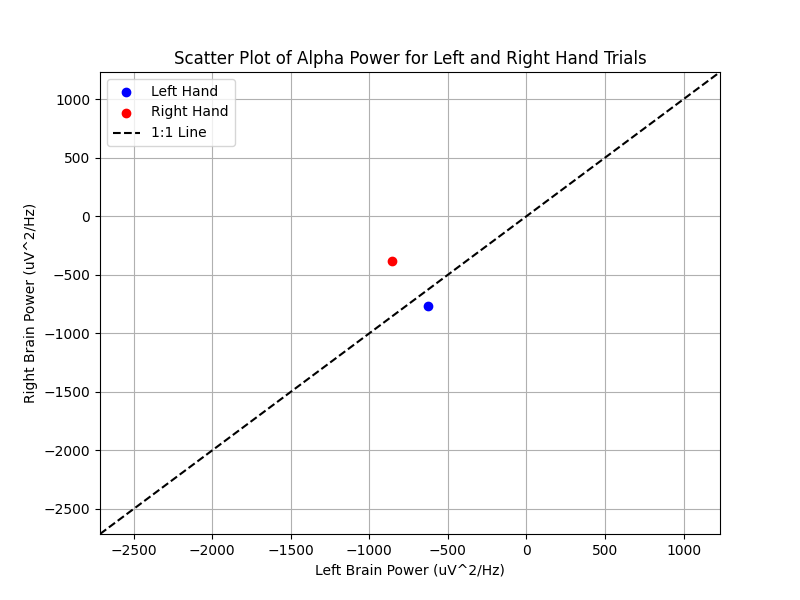

In [313]:
plt.figure(figsize=(8, 6))
plt.scatter(np.mean(all_lhlb), np.mean(all_lhrb), color='blue', label='Left Hand')
plt.scatter(np.mean(all_rhlb), np.mean(all_rhrb), color='red', label='Right Hand')
plt.xlabel('Left Brain Power (uV^2/Hz)')
plt.ylabel('Right Brain Power (uV^2/Hz)')
plt.title('Scatter Plot of Alpha Power for Left and Right Hand Trials')

# Determine limits from all data for same scaling
all_values = np.concatenate([all_lhlb, all_lhrb, all_rhlb, all_rhrb])
min_val = all_values.min()*1.1
max_val = all_values.max()*1.1
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

# Plot 1:1 line
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='1:1 Line')

plt.legend()
plt.grid()
plt.show()

In [70]:
left_hand_left_brain, left_hand_right_brain, right_hand_left_brain, right_hand_right_brain = calculate_subject_alpha_powers('001')

/var/folders/b6/20mcgwl17j75xmyj_0cxrp800000gn/T/ipykernel_68580/59796964.py:32: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = mne_icalabel.label_components(dataCopy, ica, method='iclabel')


    Using multitaper spectrum estimation with 7 DPSS windows


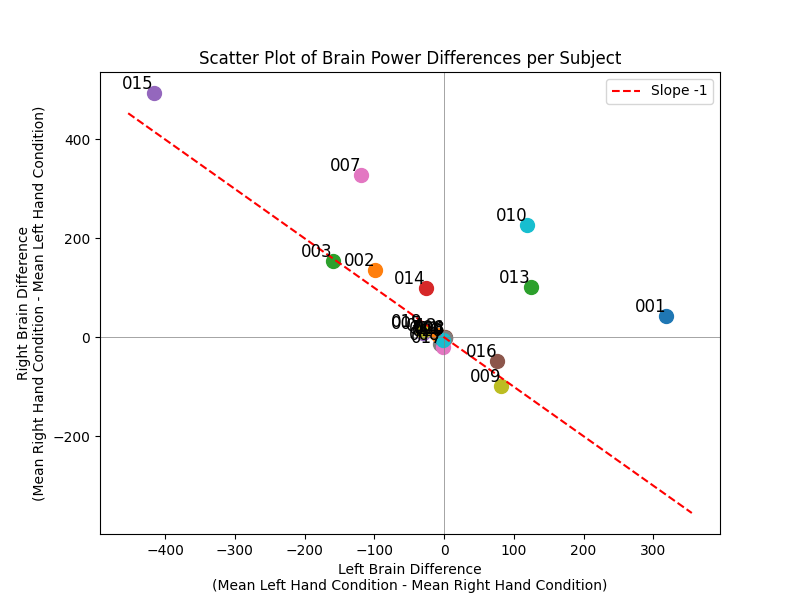

In [139]:
fig, ax = plt.subplots(figsize=(8, 6))
for i in range(len(all_left_left)):
    # Compute differences for left and right brain separately
    left_brain_diff = np.mean(all_left_left[i]) - np.mean(all_right_left[i])
    right_brain_diff = np.mean(all_right_right[i]) - np.mean(all_left_right[i])
    ax.scatter(left_brain_diff, right_brain_diff, s=100)
    # Annotate the point with the subject number
    ax.text(left_brain_diff, right_brain_diff, subjects[i],
            fontsize=12, ha='right', va='bottom')

ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)

# Add a reference line with slope -1 (y = -x)
x_vals = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 100)
ax.plot(x_vals, -x_vals, 'r--', label='Slope -1')

ax.set_xlabel('Left Brain Difference\n(Mean Left Hand Condition - Mean Right Hand Condition)')
ax.set_ylabel('Right Brain Difference\n(Mean Right Hand Condition - Mean Left Hand Condition)')
ax.set_title('Scatter Plot of Brain Power Differences per Subject')
ax.legend()
plt.show()


In [138]:
plt.close('all')

In [130]:
sum

70

LATER

In [ ]:
# subjects = ['001']
subjects = ['001','002','003']
bads = {'001':['Iz','Oz','O1','O2','Poz','Po3','Po4','Po7','Po8'],
        '002':['Iz','Oz','O1','O2','Poz','Po3','Po4','Po7','Po8','Af7','T7'],
        '003':['T7','T8']}
components = {'001':15, 
              '002':20,
              '003':15}
ica_excludes = {'001':[0,1],
        '002':[0,1],
        '003':[0,1,3,5,6,7,13,14]}

values = []

fig, axs = plt.subplots(len(subjects), 2)

for idx, subject in enumerate(subjects):
    with contextlib.redirect_stdout(open(os.devnull, 'w')):
        with contextlib.redirect_stderr(open(os.devnull, 'w')):
        #     values.append(calculate_subject_alpha_power(subject, show_plots=False, bads=bads[subject], n_components=components[subject], ica_exclude=ica_excludes[subject]))
                plot_subject_alpha_topoplot(subject, left_axes=axs[idx,0], right_axes=axs[idx,1], bads=bads[subject], n_components=components[subject], ica_exclude=ica_excludes[subject])